# 📊 Training Analysis Notebook
Elegant visualizations for RL training metrics

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from scipy.integrate import trapezoid


plt.style.use('seaborn-v0_8-darkgrid')

# Custom color palette
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

In [19]:
def stage_order(name):
    if "easy" in name:
        return 0
    elif "medium" in name:
        return 1
    elif "hard" in name:
        return 2
    elif "final" in name:
        return 3
    else:
        return 999

In [20]:
DATA_PATH = './data'
files = glob.glob(os.path.join(DATA_PATH, 'training_steps_*.csv'))

datasets = {}

curriculum_parts = []
ppo_df = None
plastic_df = None

for file in files:
    name = os.path.basename(file).lower()
    df = pd.read_csv(file).dropna()

    if "ppo-curriculum" in name:
        curriculum_parts.append((name, df))

    if "plastic" in name:
        plastic_df = df

    elif "ppo" in name:
        ppo_df = df

curriculum_parts.sort(key=lambda x: stage_order(x[0]))

In [21]:
curriculum_df = []
offset = 0

for name, df in curriculum_parts:
    df = df.copy()

    # normalizar step interno
    df["step"] = df["step"] - df["step"].min()

    # hacer continuo
    df["step"] += offset

    offset = df["step"].max()

    curriculum_df.append(df)

curriculum_df = pd.concat(curriculum_df, ignore_index=True)

datasets = {
    "PPO": ppo_df,
    "Curriculum": curriculum_df,
    "Plastic (own)": plastic_df
}

In [22]:
datasets

{'PPO':           step    reward
 0       500225  0.486387
 1       500226  0.492004
 2       500227  0.499148
 3       500228  0.507215
 4       500229  0.517429
 ...        ...       ...
 250107  750332  1.091351
 250108  750333  1.075357
 250109  750334  1.061954
 250110  750335  1.040438
 250111  750336  1.008891
 
 [250112 rows x 2 columns],
 'Curriculum':             step    reward
 0              0  0.115526
 1              1 -0.064401
 2              2  0.115526
 3              3  0.115526
 4              4 -0.082818
 ...          ...       ...
 1000443  1000440 -0.000676
 1000444  1000441 -0.010835
 1000445  1000442 -0.020835
 1000446  1000443 -0.030783
 1000447  1000444 -0.040758
 
 [1000448 rows x 2 columns],
 'Plastic (own)':         step  episode    reward  terminated  truncated
 0          1        1  0.386901           1          0
 1          2        2  0.416051           1          0
 2          3        3  0.475875           1          0
 3          4        4  0.447

## 📈 Learning Curve

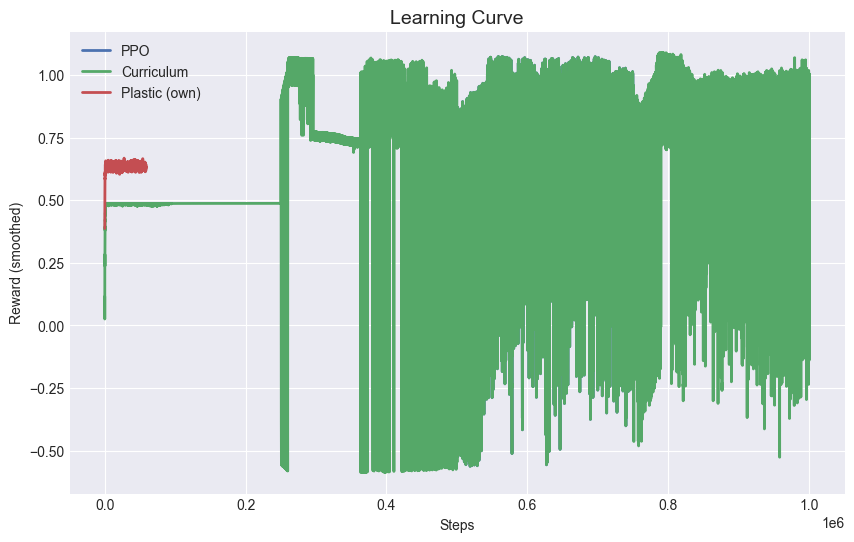

In [23]:
plt.figure(figsize=(10,6))

for i,(name,df) in enumerate(datasets.items()):
    smooth = df['reward'].rolling(100, min_periods=1).mean()
    plt.plot(df['step'], smooth, label=name, color=colors[i % len(colors)], linewidth=2)

plt.title('Learning Curve', fontsize=14)
plt.xlabel('Steps')
plt.ylabel('Reward (smoothed)')
plt.legend()
plt.show()

In [24]:
for i,(name,df) in enumerate(datasets.items()):
    print("df", name)
    print(df['reward'].describe())

df PPO
count    250112.000000
mean          0.553271
std           0.538296
min          -0.782379
25%           0.033534
50%           0.825872
75%           0.983452
max           4.144958
Name: reward, dtype: float64
df Curriculum
count    1.000448e+06
mean     5.508825e-01
std      4.568767e-01
min     -8.886876e-01
25%      4.864120e-01
50%      4.969763e-01
75%      9.435292e-01
max      4.271183e+00
Name: reward, dtype: float64
df Plastic (own)
count    58461.000000
mean         0.634578
std          0.085544
min         -0.055710
25%          0.596795
50%          0.651015
75%          0.692210
max          0.885266
Name: reward, dtype: float64


## 🎯 Steps to Threshold

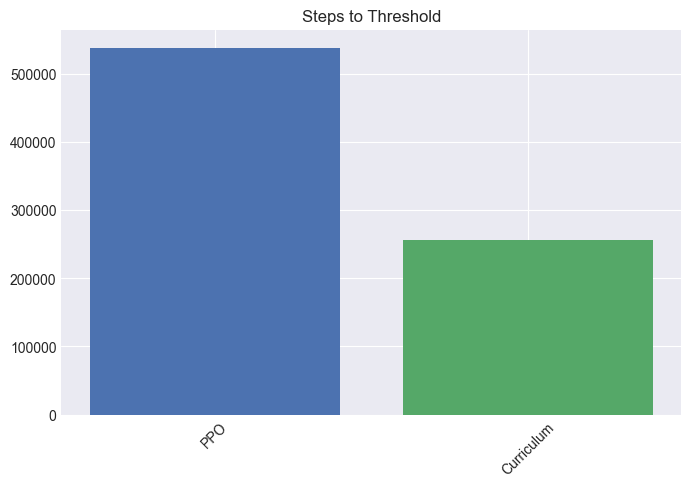

In [25]:
THRESHOLD = 1.0
results = {}

for name,df in datasets.items():
    above = df[df['reward'] >= THRESHOLD]
    results[name] = above.iloc[0]['step'] if len(above)>0 else np.nan

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=colors)
plt.title('Steps to Threshold')
plt.xticks(rotation=45)
plt.show()

## 📊 AUC

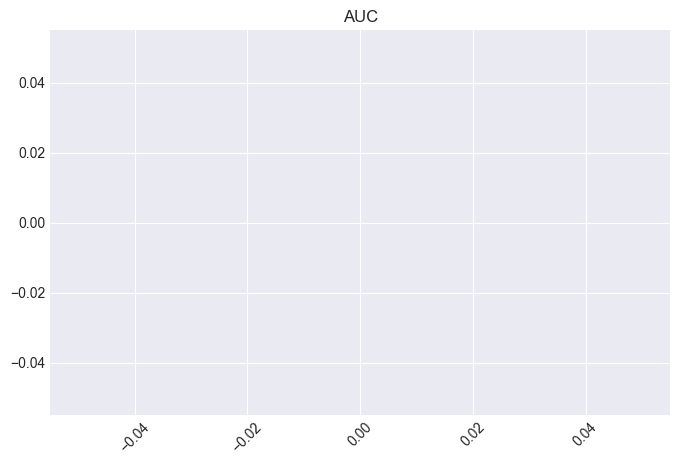

In [26]:
auc_results = {}

for name,df in datasets.items():
    auc = trapezoid(df["reward"], df["step"])

plt.figure(figsize=(8,5))
plt.bar(auc_results.keys(), auc_results.values(), color=colors)
plt.title('AUC')
plt.xticks(rotation=45)
plt.show()

## 📉 Stability

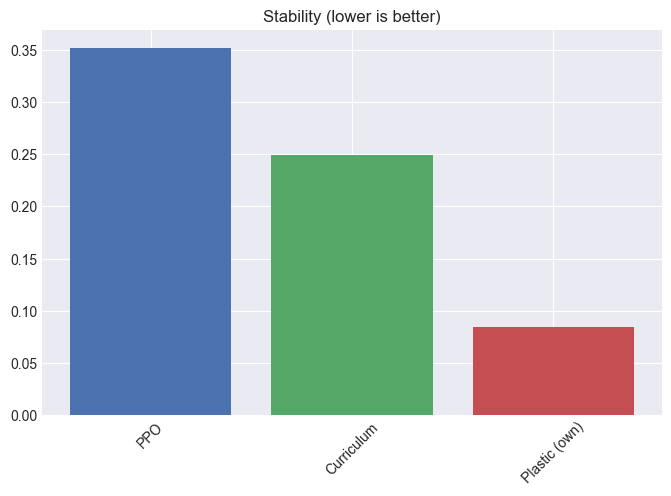

In [27]:
stability = {}

for name,df in datasets.items():
    stability[name] = df['reward'].rolling(200).std().mean()

plt.figure(figsize=(8,5))
plt.bar(stability.keys(), stability.values(), color=colors)
plt.title('Stability (lower is better)')
plt.xticks(rotation=45)
plt.show()

### Plastic analisys

In [29]:
df_plastic = datasets.get("Plastic (own)")


### metricas generales

In [ ]:
import numpy as np
from scipy.integrate import trapezoid

auc_results = {}

for name, df in datasets.items():
    # -------------------------
    # 1. order
    # -------------------------
    df = df.sort_values("step")

    # -------------------------
    # 2. clean
    # -------------------------
    steps = df["step"].values
    rewards = df["reward"].values

    mask = ~np.isnan(steps) & ~np.isnan(rewards)
    steps = steps[mask]
    rewards = rewards[mask]

    if len(steps) < 2:
        auc_results[name] = np.nan
        continue

    # -------------------------
    # 3. calculate AUC
    # -------------------------
    auc = trapezoid(rewards, steps)

    # -------------------------
    # 4. norm
    # -------------------------
    total_steps = steps[-1] - steps[0]

    if total_steps == 0:
        auc_normalized = np.nan
    else:
        auc_normalized = auc / total_steps

    auc_results[name] = auc_normalized

In [31]:
auc_results

{'PPO': np.float64(0.5532704846448091),
 'Curriculum': np.float64(0.5508835056766826),
 'Plastic (own)': np.float64(0.6345793990234267)}

In [32]:
for name, df in datasets.items():
    rewards = df["reward"].values

    print(f"Reward mean {name}", rewards.mean())

Reward mean PPO 0.5532712617722092
Reward mean Curriculum 0.5508825230477016
Reward mean Plastic (own) 0.6345775234235831
